In [1]:
# ==========================================
# SIMPLIFIED DATASET - GUARANTEED TO WORK
# ==========================================

import pandas as pd
import numpy as np

np.random.seed(42)

n_employees = 5000

# Simplified data generation
data = {
    'EmployeeID': range(1, n_employees + 1),

    # Demographics
    'Age': np.random.randint(22, 65, n_employees),

    # Compensation (using uniform + exponential)
    'MonthlyIncome': (np.random.exponential(5000, n_employees) + 3000).astype(int),

    # Tenure
    'YearsAtCompany': np.random.exponential(3, n_employees).astype(int),
    'YearsSinceLastPromotion': np.random.exponential(2, n_employees).astype(int),
    'YearsWithCurrManager': np.random.exponential(2, n_employees).astype(int),

    # Distance
    'DistanceFromHome': np.random.exponential(8, n_employees).astype(int),
    'WorkLifeBalance': np.random.randint(1, 5, n_employees),

    # Job Role
    'JobRole': np.random.choice([
        'Sales', 'Research', 'Technician', 'Manufacturing',
        'Healthcare', 'Manager', 'HR', 'Engineer'
    ], n_employees),

    'JobLevel': np.random.randint(1, 6, n_employees),
    'JobInvolvement': np.random.randint(1, 5, n_employees),

    # Work Patterns
    'BusinessTravel': np.random.choice(['Rarely', 'Frequently', 'No Travel'], n_employees),
    'OverTime': np.random.choice(['Yes', 'No'], n_employees, p=[0.25, 0.75]),
    'StockOptionLevel': np.random.randint(0, 4, n_employees),

    # Satisfaction Scores
    'JobSatisfaction': np.random.randint(1, 5, n_employees),
    'EnvironmentSatisfaction': np.random.randint(1, 5, n_employees),
    'RelationshipSatisfaction': np.random.randint(1, 5, n_employees),

    # Education
    'Education': np.random.randint(1, 6, n_employees),
    'EducationField': np.random.choice(['Science', 'Medical', 'Marketing', 'Technical', 'HR', 'Other'], n_employees),

    # Training
    'TrainingTimesLastYear': np.random.poisson(2, n_employees),
    'NumCompaniesWorked': np.random.poisson(2, n_employees),
    'PercentSalaryHike': np.random.randint(10, 26, n_employees),
    'PerformanceRating': np.random.choice([3, 4], n_employees, p=[0.85, 0.15])
}

df = pd.DataFrame(data)

# Simple churn logic
df['Attrition'] = 'No'

# Create churn flags based on rules
churn_conditions = (
    (df['OverTime'] == 'Yes') |
    (df['YearsAtCompany'] < 2) |
    (df['JobSatisfaction'] <= 2) |
    (df['EnvironmentSatisfaction'] <= 2) |
    (df['NumCompaniesWorked'] > 4) |
    (df['WorkLifeBalance'] <= 2) |
    (df['MonthlyIncome'] < 5000) |
    (df['BusinessTravel'] == 'Frequently')
)

# Set attrition with some randomness
np.random.seed(42)
random_churn = np.random.random(n_employees) < 0.3  # 30% of flagged become churn
df.loc[churn_conditions & random_churn, 'Attrition'] = 'Yes'

# Add missing values
for col in ['JobSatisfaction', 'EnvironmentSatisfaction', 'MonthlyIncome']:
    missing_idx = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
    df.loc[missing_idx, col] = np.nan

# Save
df.to_csv('employee_churn.csv', index=False)

print("="*60)
print("SIMPLIFIED DATASET CREATED!")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Attrition Rate: {(df['Attrition'] == 'Yes').mean()*100:.2f}%")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes.value_counts())

SIMPLIFIED DATASET CREATED!
Shape: (5000, 24)
Attrition Rate: 30.18%

First 5 rows:
   EmployeeID  Age  MonthlyIncome  YearsAtCompany  YearsSinceLastPromotion  \
0           1   60         3559.0               1                        0   
1           2   50        13318.0               0                        0   
2           3   36         6702.0               0                        2   
3           4   64         9014.0               4                        0   
4           5   29         5645.0               1                        5   

   YearsWithCurrManager  DistanceFromHome  WorkLifeBalance        JobRole  \
0                     3                 4                1  Manufacturing   
1                     1                 6                3       Research   
2                     4                10                4  Manufacturing   
3                     0                 0                3       Engineer   
4                     3                 6                4    

(5000, 24)
Attrition
No     3491
Yes    1509
Name: count, dtype: int64
Churn rate: 30.2%
MonthlyIncome              5.0
JobSatisfaction            5.0
EnvironmentSatisfaction    5.0
dtype: float64


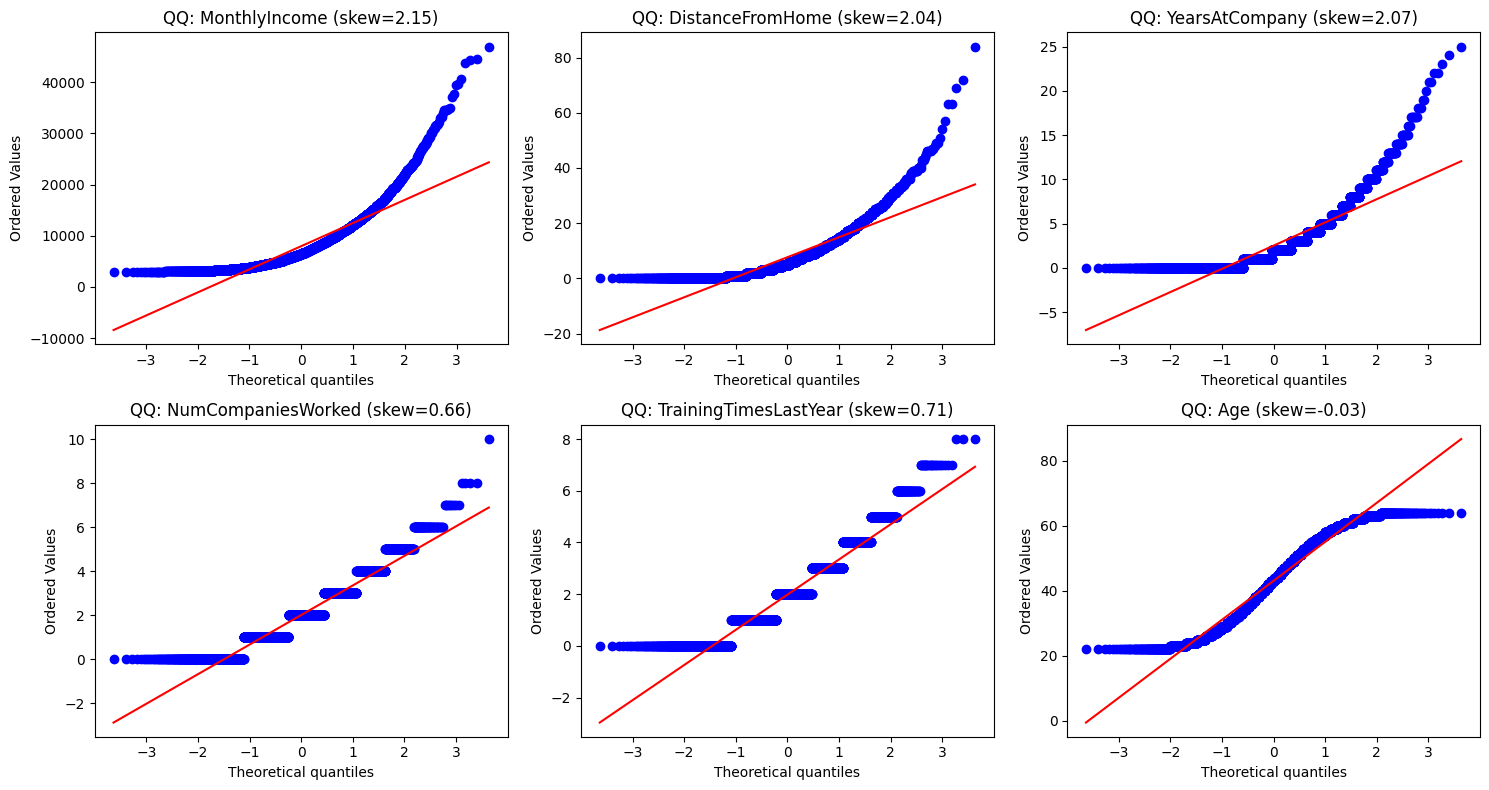

MonthlyIncome: 221 outliers (4.4%)
  Fence: [-3730.6, 18068.4]  Max=46999.0
DistanceFromHome: 222 outliers (4.4%)
  Fence: [-11.5, 24.5]  Max=84.0
YearsAtCompany: 117 outliers (2.3%)
  Fence: [-6.0, 10.0]  Max=25.0
NumCompaniesWorked: 14 outliers (0.3%)
  Fence: [-2.0, 6.0]  Max=10.0
TrainingTimesLastYear: 25 outliers (0.5%)
  Fence: [-2.0, 6.0]  Max=8.0
Age: 0 outliers (0.0%)
  Fence: [1.5, 85.5]  Max=64.0
# ═══════════════════════════════════ 

Correlation with Attrition:
MonthlyIncome              -0.035370
YearsSinceLastPromotion    -0.026447
JobSatisfaction            -0.018710
TrainingTimesLastYear      -0.016560
EnvironmentSatisfaction    -0.016067
WorkLifeBalance            -0.010614
PerformanceRating          -0.010090
Age                        -0.009943
DistanceFromHome           -0.009328
YearsWithCurrManager       -0.004319
StockOptionLevel           -0.004306
YearsAtCompany             -0.003213
JobLevel                   -0.002876
PercentSalaryHike          -0.001035
Ove

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder,
                                       OrdinalEncoder, FunctionTransformer)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

# ═══════════════════════════════════
# STEP 1 — Load data
# ═══════════════════════════════════
df = pd.read_csv('employee_churn.csv')
print(df.shape)
print(df['Attrition'].value_counts())

# ═══════════════════════════════════
# STEP 2 — Encode target: Yes=1, No=0
# ═══════════════════════════════════
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
# Why: ML models need numbers. 'Yes'==True → 1. 'No'==False → 0.
# Keep original 'Attrition' column for EDA and business reports.

print(f"Churn rate: {df['Attrition_bin'].mean()*100:.1f}%")

# ═══════════════════════════════════
# STEP 3 — Encode binary OverTime
# ═══════════════════════════════════
df['OverTime_bin'] = (df['OverTime'] == 'Yes').astype(int)

# ═══════════════════════════════════
# STEP 4 — Missing value analysis
# ═══════════════════════════════════
missing = df.isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False))
# JobSatisfaction: 5% → most_frequent (discrete 1-4, mean=2.5 invalid)
# EnvironmentSatisfaction: 5% → most_frequent (same reason)
# MonthlyIncome: 5% → KNNImputer (continuous, correlates with JobLevel)

# ═══════════════════════════════════
# STEP 5 — Distribution analysis (QQ plots)
# ═══════════════════════════════════
num_cols_eda = ['MonthlyIncome', 'DistanceFromHome',
                'YearsAtCompany', 'NumCompaniesWorked',
                'TrainingTimesLastYear', 'Age']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols_eda):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"QQ: {col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════
# STEP 6 — Outlier analysis (IQR)
# ═══════════════════════════════════
def outlier_report(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    out = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(out)} outliers ({len(out)/len(df)*100:.1f}%)")
    print(f"  Fence: [{lower:.1f}, {upper:.1f}]  Max={df[col].max():.1f}")

for col in num_cols_eda:
    outlier_report(df, col)

# ═══════════════════════════════════
# STEP 7 — Outlier decision
# ═══════════════════════════════════
# MonthlyIncome: $48k → real senior salary → KEEP + log1p
# DistanceFromHome: 80km → real commuter → KEEP + log1p
# YearsAtCompany: 20yrs → real veteran → KEEP + log1p
# NumCompaniesWorked: 10 → job hopper → KEEP + sqrt
# TrainingTimesLastYear: 8 → real → KEEP + sqrt
# Age: bounded 22-64 → no outliers → KEEP raw
# Model = XGBoost → trees handle outliers natively
# Decision: NO winsorization, NO removal

# ═══════════════════════════════════
# STEP 8 — Correlation with target → drop low-signal columns



print("# ═══════════════════════════════════ " )
df_temp = df.copy()
for col in df_temp.select_dtypes('number').columns:
    df_temp[col] = df_temp[col].fillna(df_temp[col].median())

num_features = [c for c in df_temp.select_dtypes('number').columns
                if c not in ['Attrition_bin', 'EmployeeID']]

corr = df_temp[num_features + ['Attrition_bin']].corr()['Attrition_bin']
print("\nCorrelation with Attrition:")
print(corr.drop('Attrition_bin').sort_values())

# Drop: EmployeeID (ID column), PerformanceRating (near-constant)
drop_always = ['EmployeeID', 'PerformanceRating']

# ═══════════════════════════════════
# STEP 9 — Define column groups
# ═══════════════════════════════════

# log1p group: right-skewed continuous (zeros possible)
log1p_cols = ['DistanceFromHome', 'YearsAtCompany',
              'YearsSinceLastPromotion', 'YearsWithCurrManager']

# sqrt group: discrete Poisson counts (small integers 0-10)
sqrt_cols = ['NumCompaniesWorked', 'TrainingTimesLastYear']

# scale only: bounded near-normal (no skew)
scale_cols = ['Age', 'PercentSalaryHike']

# MonthlyIncome: KNN impute first, then log1p, then scale
income_col = ['MonthlyIncome']

# ordinal integers: passthrough (meaningful order, bounded 1-5)
ordinal_int_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                    'RelationshipSatisfaction', 'WorkLifeBalance',
                    'JobLevel', 'JobInvolvement',
                    'Education', 'StockOptionLevel']

# nominal categorical: OHE
nominal_cols = ['JobRole', 'EducationField']

# ordinal categorical: ordinal encode (has real order)
ordinal_cat_cols = ['BusinessTravel']
travel_order = [['No Travel', 'Rarely', 'Frequently']]

# binary: already 0/1
binary_cols = ['OverTime_bin']

# ═══════════════════════════════════
# STEP 10 — Build sub-pipelines
# ═══════════════════════════════════

# MonthlyIncome: KNN impute (uses JobLevel correlation)
# → log1p (right skew from QQ plot) → StandardScaler
income_pipe = Pipeline([
    ('knn',   KNNImputer(n_neighbors=5)),
    ('log1p', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler()),
])

# log1p columns: log1p → scale
log1p_pipe = Pipeline([
    ('log1p', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler()),
])

# sqrt columns: sqrt → scale
sqrt_pipe = Pipeline([
    ('sqrt',  FunctionTransformer(np.sqrt)),
    ('scale', StandardScaler()),
])

# scale only: StandardScaler
scale_pipe = Pipeline([
    ('scale', StandardScaler()),
])

# ordinal integers: impute most_frequent (discrete 1-4)
# Why most_frequent not KNN: only 4 valid values, mean=2.5 invalid
ordinal_int_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
])

# nominal → OHE (no order, low cardinality)
nominal_pipe = Pipeline([
    ('ohe', OneHotEncoder(drop='first',
                          handle_unknown='ignore',
                          sparse_output=False)),
])

# ordinal categorical: No Travel=0, Rarely=1, Frequently=2
travel_pipe = Pipeline([
    ('ord', OrdinalEncoder(categories=travel_order,
                           handle_unknown='use_encoded_value',
                           unknown_value=-1)),
])

# ═══════════════════════════════════
# STEP 11 — ColumnTransformer
# ═══════════════════════════════════
preprocessor = ColumnTransformer([
    ('income',  income_pipe,      income_col),
    ('log1p',   log1p_pipe,       log1p_cols),
    ('sqrt',    sqrt_pipe,        sqrt_cols),
    ('scale',   scale_pipe,       scale_cols),
    ('ordint',  ordinal_int_pipe, ordinal_int_cols),
    ('nominal', nominal_pipe,     nominal_cols),
    ('travel',  travel_pipe,      ordinal_cat_cols),
    ('binary',  'passthrough',    binary_cols),
], remainder='drop')

# ═══════════════════════════════════
# STEP 12 — Split AFTER EDA
# ═══════════════════════════════════
X = df.drop(['Attrition', 'Attrition_bin',
             'OverTime'] + drop_always, axis=1)
y = df['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
# stratify=y → preserves churn ratio in both splits

# ═══════════════════════════════════
# STEP 13 — Fit preprocessor on TRAIN only
# ═══════════════════════════════════
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)
# fit only on train → no leakage into test

# ═══════════════════════════════════
# STEP 14 — Class imbalance
# ═══════════════════════════════════
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {spw:.2f}")

# ═══════════════════════════════════
# STEP 15 — Model + train
# ═══════════════════════════════════
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_p, y_train)

# ═══════════════════════════════════
# STEP 16 — Evaluate
# ═══════════════════════════════════
pred = model.predict(X_test_p)
prob = model.predict_proba(X_test_p)[:,1]
print(classification_report(y_test, pred))
print(f"ROC-AUC: {roc_auc_score(y_test, prob):.4f}")
